# Getting Tuolumne Data

In [1]:
import geopandas as gpd
import glob
import rasterio
import rioxarray
import os
import numpy as np

import xarray as xr
import matplotlib.pyplot as plt
from shapely.geometry import mapping
from rasterio.mask import mask

In [2]:
# create data stack
from pathlib import Path
main_folder = Path('../Dataset/Data/SWE')
tif_files = []

In [3]:
for year_folder in main_folder.iterdir():
    for tif in year_folder.glob("*.tif"):
        tif_files.append(tif)

In [4]:
tif_files = sorted(tif_files)

In [5]:
tif_data = []
for tif in tif_files:
    with rasterio.open(tif) as src:
        tif_data.append(src.read(1))

In [6]:
data_stack = np.stack(tif_data)

In [7]:
# check
print("stack shape:", data_stack.shape)

stack shape: (48, 1339, 1374)


In [8]:
# create time array
time = []
for tif  in tif_files:
    file_name = tif.name
    date = file_name[2:10]
    from pandas import to_datetime
    date = to_datetime(date)
    time.append(date)

In [9]:
# create lat/lon arrays
longs = [];
lats = [];

file = rasterio.open(tif_files[0]) 
data = file.read(1) 
height, width = data.shape 

rows, cols = np.meshgrid(np.arange(height), np.arange(width), indexing='ij') 
transform = file.transform 

longs = transform.c + cols * transform.a + rows * transform.b 
lats = transform.f + cols * transform.d + rows * transform.e 

lats_1d = lats[:, 0] # all rows, first column 
longs_1d = longs[0, :] # first row, all columns


In [10]:
# create SWE dataset
ds = xr.DataArray(
    data_stack,
    coords={"time": time, "y": lats_1d, "x": longs_1d},
    dims=("time", "y", "x"),
    name='SWE'
)

ds.attrs = {
    "long_name": "Snow Water Equivalent",
    "units": "millimeters h20"
}

# create UA SWE dataset
path_ua = '../Dataset/UA_Data/'
files_ua = path_ua + '4km_SWE_Depth*.nc'
ds_ua = xr.open_mfdataset(files_ua, engine="netcdf4", data_vars='all')

In [11]:
one_day = ds.sel(time='20130525')

In [16]:
# read shapefile
tuolumne_boundary = gpd.read_file("../Dataset/TuolumneBasin.geojson") 
tuolumne_boundary = tuolumne_boundary.set_crs("EPSG:5070", allow_override=True) 
tuolumne_boundary = tuolumne_boundary.to_crs("epsg:26911")

In [17]:
tuolumne_boundary

,Id,geometry
0,0,"POLYGON Z ((273242.995 4229670.985 0, 273249.6..."


In [18]:
poly = tuolumne_boundary.geometry.to_list()

tuolumne_clipped = ds.rio.set_spatial_dims(x_dim='x', y_dim='y', inplace=True)
tuolumne_clipped = tuolumne_clipped.rio.write_crs('epsg:26911', inplace=True)
tuolumne_clipped = tuolumne_clipped.rio.clip(poly, crs='epsg:26911')

In [ ]:
# change everything to decimal degrees
tuolumne_clipped = tuolumne_clipped.rio.reproject("EPSG:4326")
tuolumne_clipped = tuolumne_clipped.where(tuolumne_clipped > 0)

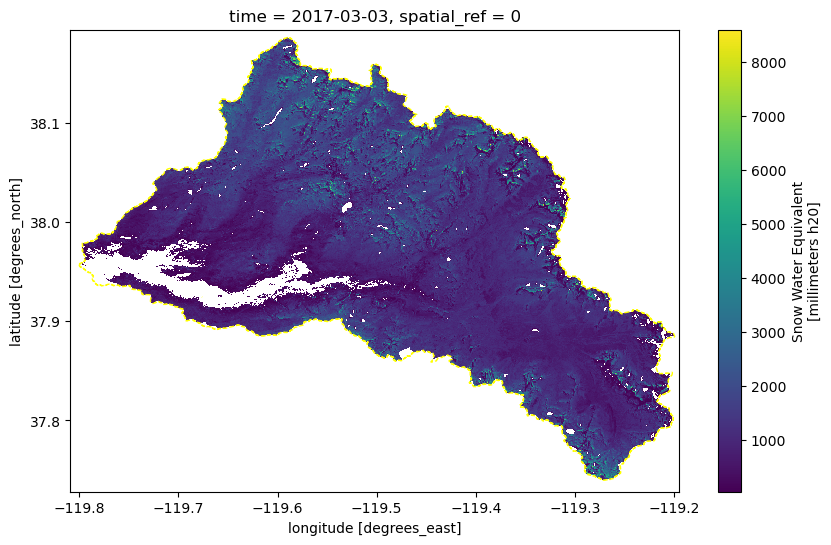

In [19]:
# plot for tuolumne basin
fig, ax = plt.subplots(figsize=(10,6))

one_day = tuolumne_clipped.sel(time='2017/03/03', method='nearest')
one_day.plot(ax=ax)

tuolumne_boundary = tuolumne_boundary.to_crs("epsg:4326")

tuolumne_boundary.plot(ax=ax, edgecolor='yellow', linestyle='--', facecolor='none')
ax.set_aspect(1)

In [20]:
# read shapefile
UA_tuolumne_bounds = gpd.read_file("../Dataset/TuolumneBasin.geojson") 
UA_tuolumne_bounds = UA_tuolumne_bounds.set_crs("EPSG:5070", allow_override=True) 
UA_tuolumne_bounds = UA_tuolumne_bounds.to_crs("EPSG:4326")

In [21]:
poly = UA_tuolumne_bounds.geometry.to_list()
ua_tuolumne_clipped = ds_ua.SWE.rio.set_spatial_dims(x_dim='lon', y_dim='lat', inplace=True)
ua_tuolumne_clipped = ua_tuolumne_clipped.rio.write_crs("epsg:4326", inplace=True)
ua_tuolumne_clipped = ua_tuolumne_clipped.rio.clip(poly, crs="epsg:4326")

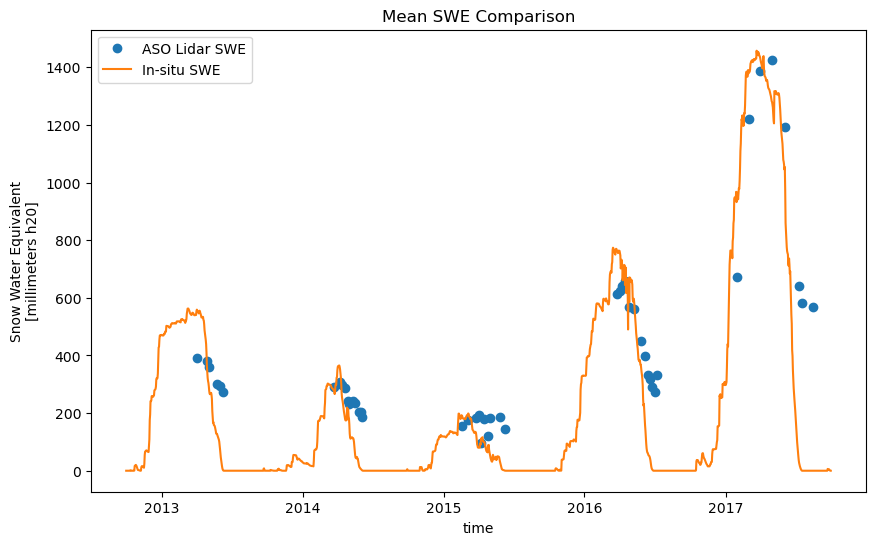

In [22]:
fig, ax = plt.subplots(figsize=(10,6))

tuolumne_clipped_mean = tuolumne_clipped.mean(dim= ('x', 'y'))
tuolumne_clipped_mean.plot(ax=ax, marker='o', linestyle='none', label='ASO Lidar SWE')

# plot UA SWE data
ua_tuolumne_clipped_mean = ua_tuolumne_clipped.mean(dim=('lat', 'lon'))
ua_tuolumne_clipped_mean.plot(ax=ax, label='In-situ SWE')

ax.set_title('Mean SWE Comparison')
ax.legend()